In [3]:
import sys
sys.path.insert(0, r'E:\flowers\tf_env\Lib\site-packages')

import tensorflow as tf
print(tf.__version__)

2.21.0


In [4]:
exec(open('setup.py').read())
import tensorflow as tf

In [6]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
import os

# Sesuaikan dengan lokasi sebenarnya
data_dir = r'E:\flowers\flowers'  # Perhatikan: E:\flowers\flowers (double flowers)

if os.path.exists(data_dir):
    print(f"✅ Berhasil! Path: {data_dir}")
    print(f"Isi: {os.listdir(data_dir)}")
else:
    print(f"❌ Path tidak ditemukan: {data_dir}")
    
    # Cek isi E:\flowers
    parent_dir = r'E:\flowers'
    if os.path.exists(parent_dir):
        print(f"Isi {parent_dir}: {os.listdir(parent_dir)}")

✅ Berhasil! Path: E:\flowers\flowers
Isi: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


Kelas yang dipilih: ['Rose', 'Tulip', 'Sunflower']
Jumlah kelas: 3
  rose: 784 gambar
  tulip: 984 gambar
  sunflower: 733 gambar

Total gambar: 2501

Resize gambar ke 128x128...

Split selesai:
  Train: 1750
  Val: 375
  Test: 376

Distribusi Train: [549 688 513]
Distribusi Val: [117 148 110]
Distribusi Test: [118 148 110]


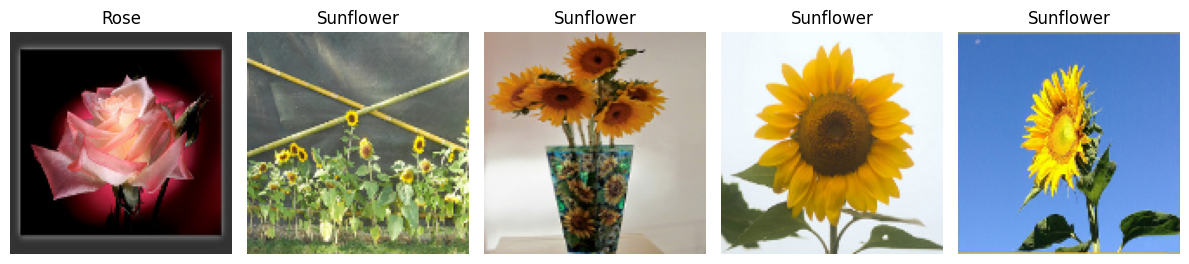

In [11]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Path yang benar
data_dir = r'E:\flowers\flowers'

# Pilih 3 kelas
selected_classes = ['rose', 'tulip', 'sunflower']
class_names = ['Rose', 'Tulip', 'Sunflower']

print(f"Kelas yang dipilih: {class_names}")
print(f"Jumlah kelas: {len(class_names)}")

# Load dataset
def load_data(data_dir, selected_classes):
    images, labels = [], []
    for idx, cls in enumerate(selected_classes):
        class_path = os.path.join(data_dir, cls)
        if not os.path.exists(class_path):
            print(f"Folder tidak ditemukan: {class_path}")
            continue
        files = [f for f in os.listdir(class_path) if f.endswith(('.jpg','.jpeg','.png'))]
        print(f"  {cls}: {len(files)} gambar")
        for f in files:
            img = cv2.imread(os.path.join(class_path, f))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img)
                labels.append(idx)
    return np.array(images, dtype=object), np.array(labels)

# Load dataset
images, labels = load_data(data_dir, selected_classes)
print(f"\nTotal gambar: {len(images)}")

# Preprocessing: Resize & normalisasi
print("\nResize gambar ke 128x128...")
X = np.array([cv2.resize(img, (128, 128)) for img in images]) / 255.0
y = labels

# Split dataset
x_train, x_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nSplit selesai:")
print(f"  Train: {len(x_train)}")
print(f"  Val: {len(x_val)}")
print(f"  Test: {len(x_test)}")
print(f"\nDistribusi Train: {np.bincount(y_train)}")
print(f"Distribusi Val: {np.bincount(y_val)}")
print(f"Distribusi Test: {np.bincount(y_test)}")

# Tampilkan sample
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for i in range(5):
    idx = np.random.randint(0, len(x_train))
    axes[i].imshow(x_train[idx])
    axes[i].set_title(class_names[y_train[idx]])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

MODEL CNN

In [12]:


from tensorflow.keras import layers, models

def build_cnn_model(input_shape=(128, 128, 3), num_classes=3):
    model = models.Sequential([
        # Input
        layers.Input(shape=input_shape),
        
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        # Global Average Pooling (lebih baik dari Flatten)
        layers.GlobalAveragePooling2D(),
        
        # Dense layers
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # Output
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Build model
model = build_cnn_model(num_classes=3)
model.summary()

print(f"Total parameters: {model.count_params():,}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 166,435 (650.14 KB)

 Trainable params: 165,411 (646.14 KB)

 Non-trainable params: 1,024 (4.00 KB)

Total parameters: 166,435


In [20]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# One-hot encoding
y_train_cat = to_categorical(y_train, 3)
y_val_cat = to_categorical(y_val, 3)
y_test_cat = to_categorical(y_test, 3)

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Custom callback: hanya save jika validation accuracy >= 85%
class SaveIfAboveThreshold(tf.keras.callbacks.Callback):
    def __init__(self, filepath='best_model.h5', threshold=0.85):
        super().__init__()
        self.filepath = filepath
        self.threshold = threshold
        self.best_acc = 0
    
    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy')
        if val_acc >= self.threshold and val_acc > self.best_acc:
            self.best_acc = val_acc
            self.model.save(self.filepath)
            print(f"\nModel SAVED! (Epoch {epoch+1}, Val Acc: {val_acc*100:.2f}% ≥ {self.threshold*100}%)")

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001),
    SaveIfAboveThreshold(filepath='best_model.h5', threshold=0.85)  # Hanya save jika >= 85%
]

print("Memulai training...")
print("Model akan disimpan HANYA jika validation accuracy >= 85%\n")

# Training
history = model.fit(
    datagen.flow(x_train, y_train_cat, batch_size=32),
    validation_data=(x_val, y_val_cat),
    epochs=40,
    callbacks=callbacks,
    verbose=1
)

# Evaluasi
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"\nTesting Accuracy: {test_acc*100:.2f}%")

# Simpan final model hanya jika testing accuracy >= 85%
if test_acc >= 0.85:
    model.save('final_model.h5')
    print(f"Final model saved! (Testing Acc: {test_acc*100:.2f}%)")
else:
    print(f"⏸ Final model not saved (Testing Acc: {test_acc*100:.2f}% < 85%)")

Memulai training...
Model akan disimpan HANYA jika validation accuracy >= 85%

Epoch 1/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.7891 - loss: 0.4912 - val_accuracy: 0.7813 - val_loss: 0.6008 - learning_rate: 0.0010
Epoch 2/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7971 - loss: 0.4807 - val_accuracy: 0.7787 - val_loss: 0.5596 - learning_rate: 0.0010
Epoch 3/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.8143 - loss: 0.4543 - val_accuracy: 0.8000 - val_loss: 0.4799 - learning_rate: 0.0010
Epoch 4/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.8086 - loss: 0.4645 - val_accuracy: 0.7787 - val_loss: 0.5030 - learning_rate: 0.0010
Epoch 5/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.8069 - loss: 0.4441 - val_accuracy: 0.8107 - val_loss: 0.4537 - learning_rate: 0.0010
Epoch 6/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.8171 - loss: 0.4378 - val_accuracy: 0.7493 - val_loss: 0.5435 - learning_rate: 0.0010
Epoch 7/40
55/55 ━━━━


Model SAVED! (Epoch 12, Val Acc: 86.40% ≥ 85.0%)
55/55 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.8320 - loss: 0.4001 - val_accuracy: 0.8640 - val_loss: 0.3913 - learning_rate: 0.0010
Epoch 13/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.8291 - loss: 0.4170 - val_accuracy: 0.8267 - val_loss: 0.4586 - learning_rate: 0.0010
Epoch 14/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8320 - loss: 0.3935 - val_accuracy: 0.8240 - val_loss: 0.4662 - learning_rate: 0.0010
Epoch 15/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8389 - loss: 0.3906 - val_accuracy: 0.8427 - val_loss: 0.4110 - learning_rate: 0.0010
Epoch 16/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8514 - loss: 0.3678 - val_accuracy: 0.8000 - val_loss: 0.5081 - learning_rate: 0.0010
Epoch 17/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8240 - loss: 0.4334 - val_accuracy: 0.8107 - val_loss: 0.4588 - learning_rate: 0.0010
Epoch 18/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accu


Model SAVED! (Epoch 18, Val Acc: 87.47% ≥ 85.0%)
55/55 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.8520 - loss: 0.3887 - val_accuracy: 0.8747 - val_loss: 0.3421 - learning_rate: 5.0000e-04
Epoch 19/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8703 - loss: 0.3312 - val_accuracy: 0.8640 - val_loss: 0.3396 - learning_rate: 5.0000e-04
Epoch 20/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8720 - loss: 0.3241 - val_accuracy: 0.8267 - val_loss: 0.4092 - learning_rate: 5.0000e-04
Epoch 21/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8686 - loss: 0.3256 - val_accuracy: 0.8747 - val_loss: 0.3589 - learning_rate: 5.0000e-04
Epoch 22/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8766 - loss: 0.3185 - val_accuracy: 0.8453 - val_loss: 0.3726 - learning_rate: 5.0000e-04
Epoch 23/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.8766 - loss: 0.3228 - val_accuracy: 0.8480 - val_loss: 0.3677 - learning_rate: 5.0000e-04
Epoch 24/40
55/55 ━━━━━━━━━━━━━━


Model SAVED! (Epoch 28, Val Acc: 88.00% ≥ 85.0%)
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8966 - loss: 0.2534 - val_accuracy: 0.8800 - val_loss: 0.3378 - learning_rate: 2.5000e-04
Epoch 29/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8958 - loss: 0.2507


Model SAVED! (Epoch 29, Val Acc: 88.53% ≥ 85.0%)
55/55 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.8914 - loss: 0.2769 - val_accuracy: 0.8853 - val_loss: 0.3228 - learning_rate: 2.5000e-04
Epoch 30/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8846 - loss: 0.2743 - val_accuracy: 0.8827 - val_loss: 0.3354 - learning_rate: 2.5000e-04
Epoch 31/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8931 - loss: 0.2709 - val_accuracy: 0.8720 - val_loss: 0.3343 - learning_rate: 2.5000e-04
Epoch 32/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9030 - loss: 0.2512


Model SAVED! (Epoch 32, Val Acc: 88.80% ≥ 85.0%)
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8954 - loss: 0.2715 - val_accuracy: 0.8880 - val_loss: 0.3315 - learning_rate: 1.2500e-04
Epoch 33/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9149 - loss: 0.2388 - val_accuracy: 0.8853 - val_loss: 0.3339 - learning_rate: 1.2500e-04
Epoch 34/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8983 - loss: 0.2587 - val_accuracy: 0.8853 - val_loss: 0.3331 - learning_rate: 1.2500e-04
Epoch 35/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9160 - loss: 0.2298 - val_accuracy: 0.8853 - val_loss: 0.3311 - learning_rate: 1.2500e-04
Epoch 36/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9029 - loss: 0.2483 - val_accuracy: 0.8773 - val_loss: 0.3224 - learning_rate: 1.2500e-04
Epoch 37/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9154 - loss: 0.2179 - val_accuracy: 0.8880 - val_loss: 0.3274 - learning_rate: 6.2500e-05
Epoch 38/40
55/55 ━━━━━━━━━━━━━━


Model SAVED! (Epoch 40, Val Acc: 89.07% ≥ 85.0%)
55/55 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9069 - loss: 0.2401 - val_accuracy: 0.8907 - val_loss: 0.3129 - learning_rate: 6.2500e-05



Testing Accuracy: 85.11%
Final model saved! (Testing Acc: 85.11%)


PLOT LOSS DAN ACCURACY

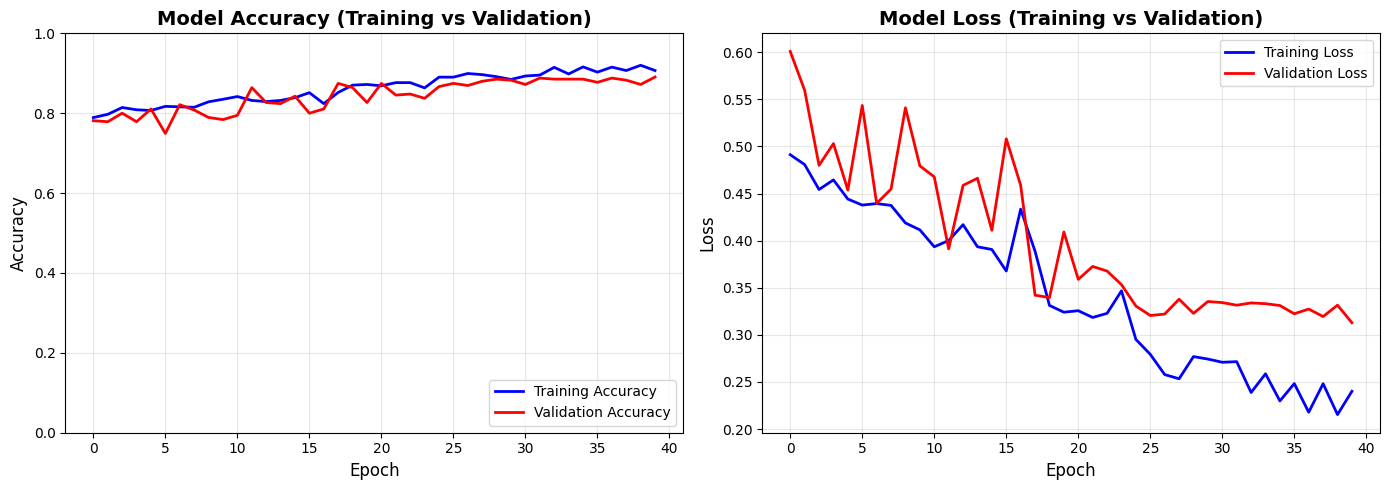

Best Validation Accuracy: 89.07%
Best Validation Loss: 0.3129


In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
axes[0].plot(history.history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy (Training vs Validation)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Plot Loss
axes[1].plot(history.history['loss'], 'b-', label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss (Training vs Validation)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')  # Simpan sebagai file
plt.show()

print(f"Best Validation Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")
print(f"Best Validation Loss: {min(history.history['val_loss']):.4f}")

CONFUSION MATRIX

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 194ms/step
CONFUSION MATRIX


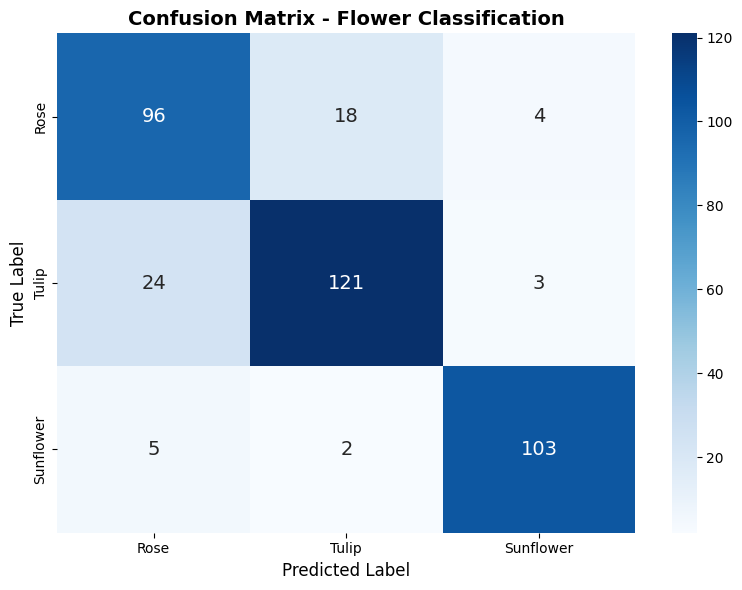


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Rose       0.77      0.81      0.79       118
       Tulip       0.86      0.82      0.84       148
   Sunflower       0.94      0.94      0.94       110

    accuracy                           0.85       376
   macro avg       0.85      0.86      0.85       376
weighted avg       0.85      0.85      0.85       376


AKURASI PER KELAS
  Rose: 81.36%
  Tulip: 81.76%
  Sunflower: 93.64%
RINGKASAN METRIK
  Accuracy : 85.11%
  Precision: 85.27%
  Recall   : 85.11%
  F1-Score : 85.15%


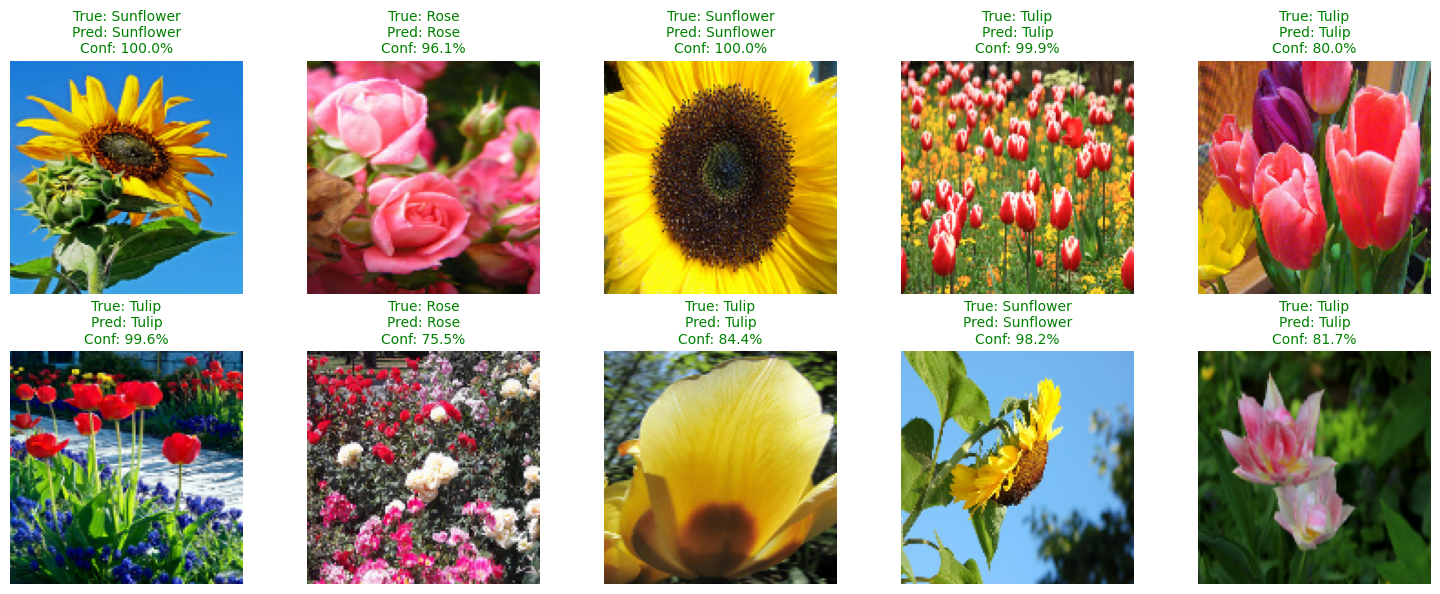


 Semua matriks evaluasi selesai!
File yang dihasilkan:
  - confusion_matrix.png
  - sample_predictions.png


In [22]:


from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Prediksi pada data test
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test

# 1. CONFUSION MATRIX
print("CONFUSION MATRIX")


cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size': 14})
plt.title('Confusion Matrix - Flower Classification', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# 2. CLASSIFICATION REPORT
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# 3. AKURASI PER KELAS
print("\n" + "="*50)
print("AKURASI PER KELAS")
print("="*50)

for i, name in enumerate(class_names):
    mask = (y_true == i)
    if np.sum(mask) > 0:
        class_acc = np.sum(y_pred_classes[mask] == i) / np.sum(mask) * 100
        print(f"  {name}: {class_acc:.2f}%")
    else:
        print(f"  {name}: No samples")

# 4. RINGKASAN METRIK
print("RINGKASAN METRIK")


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

print(f"  Accuracy : {accuracy*100:.2f}%")
print(f"  Precision: {precision*100:.2f}%")
print(f"  Recall   : {recall*100:.2f}%")
print(f"  F1-Score : {f1*100:.2f}%")

# 5. SAMPLE PREDICTION VISUALIZATION



fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

random_indices = np.random.choice(len(x_test), 10, replace=False)

for i, idx in enumerate(random_indices):
    img = x_test[idx]
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred_classes[idx]]
    confidence = np.max(y_pred[idx]) * 100
    
    color = 'green' if true_label == pred_label else 'red'
    
    axes[i].imshow(img)
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%', 
                      color=color, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()

print("\n Semua matriks evaluasi selesai!")
print("File yang dihasilkan:")
print("  - confusion_matrix.png")
print("  - sample_predictions.png")

In [7]:
import sys
sys.path.insert(0, r'E:\flowers\tf_env\Lib\site-packages')

import tensorflow as tf
print(tf.__version__)

2.21.0


In [ ]:



def convert_model(model):
   
    if os.path.exists('submission'):
        shutil.rmtree('submission')
    os.makedirs('submission', exist_ok=True)

    print("Memulai proses konversi...")

   
    model.export('submission/saved_model')
    print("SavedModel berhasil diekspor ke folder submission/saved_model!")

    converter = tf.lite.TFLiteConverter.from_saved_model('submission/saved_model')
    tflite_model = converter.convert()

    os.makedirs('submission/tflite', exist_ok=True)
    with open('submission/tflite/model.tflite', 'wb') as f:
        f.write(tflite_model)
    print("TFLite model berhasil disimpan!")

  
    class_names = ['Cyst', 'Normal', 'Stone', 'Tumor']
    with open('submission/tflite/labels.txt', 'w') as f:
        for label in class_names:
            f.write(label + '\n')
    print("labels.txt berhasil dibuat!")

    print("⏳ Mengonversi ke format TFJS (mungkin butuh waktu)...")
    tfjs.converters.convert_tf_saved_model(
        'submission/saved_model', 
        'submission/tfjs_model'
    )
   

    

# Panggil fungsi (pastikan variabel 'model' sudah ada)
if __name__ == "__main__":
    # Contoh jika model sudah di-load:
    # model = tf.keras.models.load_model('best_model.h5')
    # convert_model(model)
    pass